# WarpKriging with categorical warping (R)

The **categorical** warp embeds each level $\ell \in \{0, \ldots, L-1\}$ into $\mathbb{R}^q$
via a learned embedding vector. This is appropriate when one input is unordered and discrete
(e.g., material type, solver choice).

Here we discretize $x_1$ of the Branin function into 5 categories while keeping $x_2$ continuous.

Steps:
1. Install rlibkriging (run once)
2. Load rlibkriging
3. Define the Branin function and plot it
4. Build a space-filling design and evaluate it
5. Fit a `WarpKriging` model
6. Predict on a fine grid and plot mean + uncertainty
7. Inspect model parameters

## 0. Installation (run once)

Build the C++ core and the R binding from source.
Requires: `cmake`, a C++ compiler, and R development headers.

The script `tools/r-linux-macos/build.sh` calls `tools/linux-macos/build.sh`
to build the C++ core, then runs `make` in `bindings/R` to compile and install
**rlibkriging** into `bindings/R/Rlibs`.

In [8]:
# Run this cell once to build and install rlibkriging.
# Skip if already built (bindings/R/Rlibs/rlibkriging exists).
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source…")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed — check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

rlibkriging already built, skipping.


## 1. Load rlibkriging

In [9]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
library(rlibkriging, lib.loc = lib_path)

## 2. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).
It has three global minima.

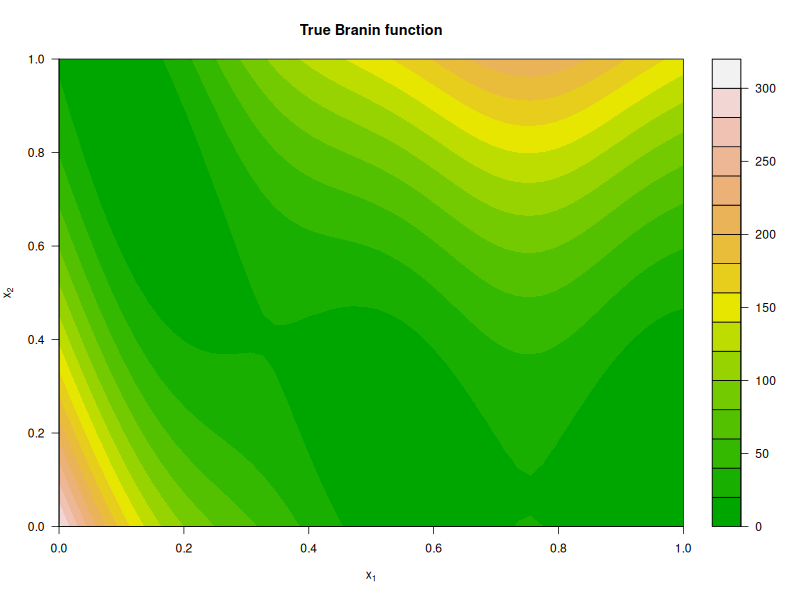

In [10]:
branin <- function(x) {
  if (!is.matrix(x)) x <- matrix(x, nrow = 1)
  x1 <- x[, 1] * 15 - 5
  x2 <- x[, 2] * 15
  (x2 - 5 / (4 * pi^2) * x1^2 + 5 / pi * x1 - 6)^2 +
    10 * (1 - 1 / (8 * pi)) * cos(x1) + 10
}

# Visualise true function on a 50x50 grid
grid_x <- seq(0, 1, length.out = 50)
grid   <- as.matrix(expand.grid(x1 = grid_x, x2 = grid_x))
z_true <- matrix(branin(grid), 50, 50)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = "True Branin function",
  xlab = expression(x[1]), ylab = expression(x[2])
)

## 3. Design of experiments

We discretize $x_1$ into 5 categories (0, 1, ..., 4), each mapped to an
equally spaced center in $[0, 1]$, and sample $n = 40$ points.

   x1_level         x2
1         0 0.85093480
2         4 0.58150362
3         0 0.55666885
4         0 0.63660597
5         1 0.14994318
6         3 0.88477656
7         1 0.02907996
8         1 0.05621194
9         0 0.53868171
10        3 0.51160525
11        0 0.83656558
12        4 0.94996548
13        3 0.99110835
14        1 0.90969667
15        1 0.22927645
16        2 0.19108195
17        0 0.11473412
18        0 0.01066310
19        2 0.41025804
20        3 0.15700857
21        4 0.09012567
22        4 0.30201990
23        4 0.65093574
24        3 0.21916191
25        1 0.45688756
26        3 0.27740914
27        2 0.48491315
28        1 0.78421232
29        0 0.25156535
30        1 0.80373793
31        2 0.96050448
32        1 0.60446490
33        3 0.69715703
34        3 0.43088731
35        1 0.33440966
36        4 0.74628883
37        3 0.77299339
38        4 0.71339826
39        3 0.38051580
40        1 0.35666180


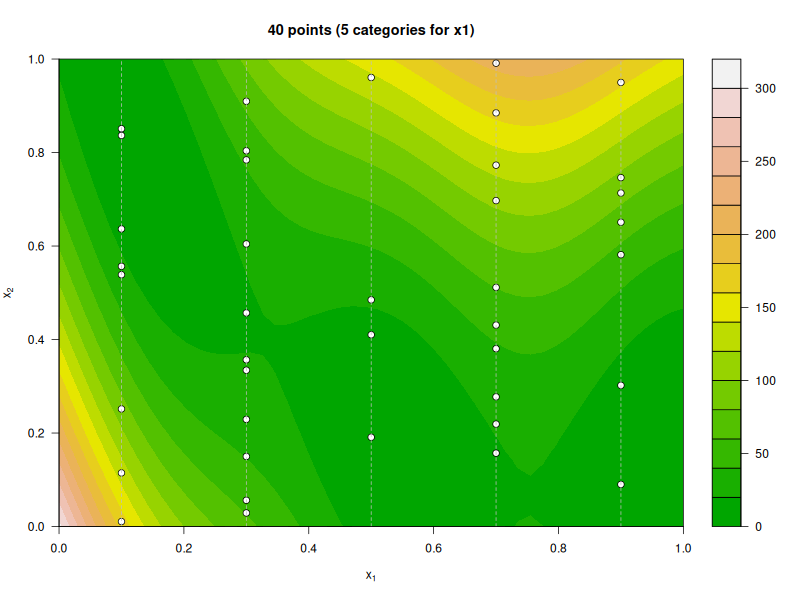

In [11]:
set.seed(42)
L <- 5  # number of categories
n <- 40
centers <- seq(0.1, 0.9, length.out = L)

lhs <- function(n, d) {
  X <- matrix(NA, n, d)
  for (j in seq_len(d))
    X[, j] <- (sample(n) - runif(n)) / n
  X
}

# x1 is categorical: randomly assign levels
x1_level <- sample(0:(L - 1), n, replace = TRUE)
x2 <- lhs(n, 1)[, 1]

# Evaluate Branin at the level's center for x1
X_eval <- cbind(centers[x1_level + 1], x2)
y <- branin(X_eval)
X_eval[, 1] <- paste0(X_eval[, 1])

# For WarpKriging, x1 is passed as integer level (0..L-1)
X <- data.frame(x1_level, x2)
# convert first column to factor, so that it is treated as categorical by WarpKriging
X$x1_level <- as.factor(X$x1_level)
print(X)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = paste0(n, " points (", L, " categories for x1)"),
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(as.numeric(X_eval[, 1]), X_eval[, 2], pch = 21, bg = "white", cex = 1.2)
    for (lvl in seq_len(L))
      abline(v = centers[lvl], col = "grey", lty = 2)
  }
)

## 4. Fit a WarpKriging model (`categorical`)

We use `categorical(5,2)` for $x_1$ (5 levels → $\mathbb{R}^2$ embedding) and `kumaraswamy`
for the continuous $x_2$.

In [12]:
print(X)
wk <- WarpKriging(
  y, X,
  warping = c('categorical(5,2)', 'none'),
  kernel = "matern5_2",
  optim = "Adam",
  parameters = list(max_iter_adam = '500')
)
print(wk)

   x1_level         x2
1         0 0.85093480
2         4 0.58150362
3         0 0.55666885
4         0 0.63660597
5         1 0.14994318
6         3 0.88477656
7         1 0.02907996
8         1 0.05621194
9         0 0.53868171
10        3 0.51160525
11        0 0.83656558
12        4 0.94996548
13        3 0.99110835
14        1 0.90969667
15        1 0.22927645
16        2 0.19108195
17        0 0.11473412
18        0 0.01066310
19        2 0.41025804
20        3 0.15700857
21        4 0.09012567
22        4 0.30201990
23        4 0.65093574
24        3 0.21916191
25        1 0.45688756
26        3 0.27740914
27        2 0.48491315
28        1 0.78421232
29        0 0.25156535
30        1 0.80373793
31        2 0.96050448
32        1 0.60446490
33        3 0.69715703
34        3 0.43088731
35        1 0.33440966
36        4 0.74628883
37        3 0.77299339
38        4 0.71339826
39        3 0.38051580
40        1 0.35666180
* WarpKriging
  - kernel:      matern5_2
  - regmodel:   

## 5. Predict and plot

We predict at each level over a dense grid for $x_2$.

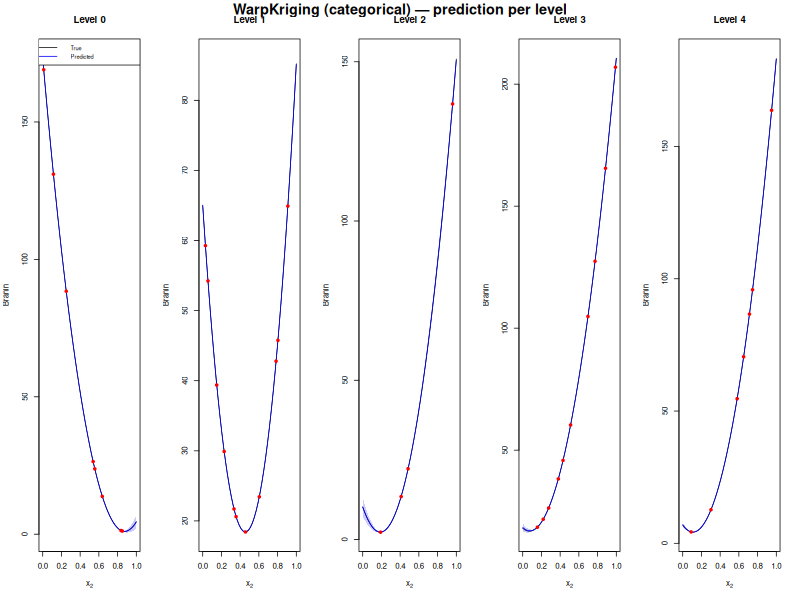

In [13]:
x2_grid <- seq(0, 1, length.out = 50)

par(mfrow = c(1, L))
for (lvl in 0:(L - 1)) {
  X_pred <- cbind(rep(lvl, 50), x2_grid)
  p <- predict(wk, X_pred, return_stdev = TRUE)
  mu <- as.numeric(p$mean)
  sd <- as.numeric(p$stdev)

  # True Branin at this level's center
  X_true <- cbind(rep(centers[lvl + 1], 50), x2_grid)
  y_true <- branin(X_true)

  ylims <- range(c(y_true, mu - 2*sd, mu + 2*sd))
  plot(x2_grid, y_true, type = "l", col = "black", ylim = ylims,
       main = paste("Level", lvl), xlab = expression(x[2]), ylab = "Branin")
  lines(x2_grid, mu, col = "blue")
  polygon(c(x2_grid, rev(x2_grid)),
          c(mu - 2*sd, rev(mu + 2*sd)),
          col = rgb(0, 0, 1, 0.2), border = NA)

  mask <- x1_level == lvl
  points(x2[mask], y[mask], col = "red", pch = 19, cex = 0.8)

  if (lvl == 0) legend("topright", legend = c("True", "Predicted"),
                        col = c("black", "blue"), lty = 1, cex = 0.7)
}
par(mfrow = c(1, 1))
title(paste0("WarpKriging (categorical) — prediction per level"), outer = TRUE, line = -1)

## 6. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, log-likelihood, and warping specification.

In [14]:
cat("Kernel       :", kernel(wk), "\n")
cat("Theta (range):", round(theta(wk), 4), "\n")
cat("Sigma2       :", round(sigma2(wk), 4), "\n")
cat("LogLikelihood:", round(logLikelihood(wk), 4), "\n")
cat("Warping      :", warping(wk), "\n")

Kernel       : matern5_2 
Theta (range): 22.631 0.8688 3.8382 
Sigma2       : 254133.8 
LogLikelihood: -79.3512 
Warping      : categorical(["0","1","2","3","4"],2) none 
